In [153]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pymc as pm
import pandas as pd

In [154]:
# getting n random values for beta in (x,y) =  (x,y,10)
np.random.beta(1,1,10)

array([0.63620141, 0.11542555, 0.9766248 , 0.38194235, 0.50849369,
       0.12738028, 0.92381777, 0.19353963, 0.40910753, 0.18510699])

In [155]:
#alpha = n of succsesses
prior_alpha = 1

#beta = n of non sucesses
prior_beta = 1 

prior1_1 = np.random.beta(prior_alpha,prior_beta,10000)

<Axes: ylabel='Density'>

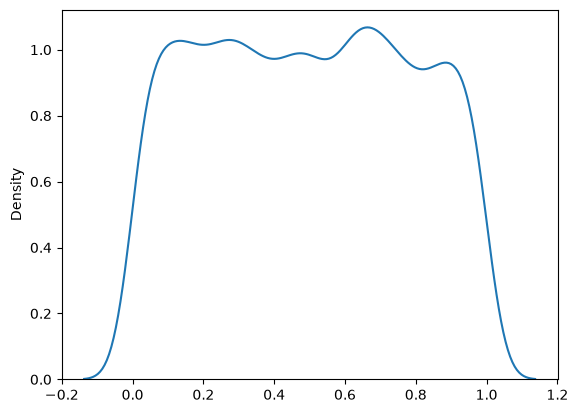

In [156]:
sns.kdeplot(prior1_1)

In [157]:
prior_alpha = 10
prior_beta = 10

In [158]:
prior10_10 = np.random.beta(prior_alpha,prior_beta,10000)


<Axes: ylabel='Density'>

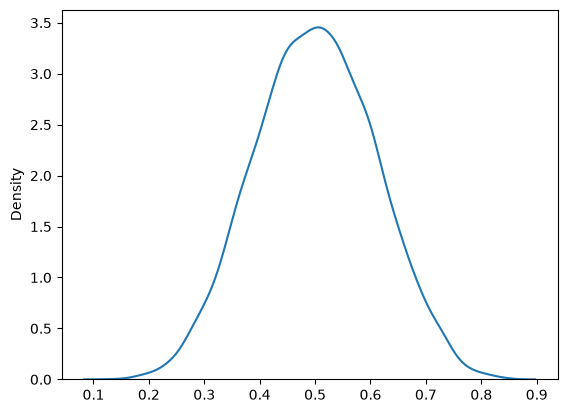

In [159]:
sns.kdeplot(prior10_10)

PYMC

In [160]:
# Highest  Density Interval (HDI), confidence level
pm.stats.hdi(prior10_10, prob = 0.95)

array([0.29350437, 0.71450766])

In [161]:
#   beta(100,100)

prior_alpha = 100
prior_beta = 100


In [162]:
prior100_100 = np.random.beta(prior_alpha,prior_beta,10000)


In [163]:
pm.stats.hdi(prior100_100, prob = 0.95)


array([0.42902042, 0.5642066 ])

# agnostic, weak and strong beta 

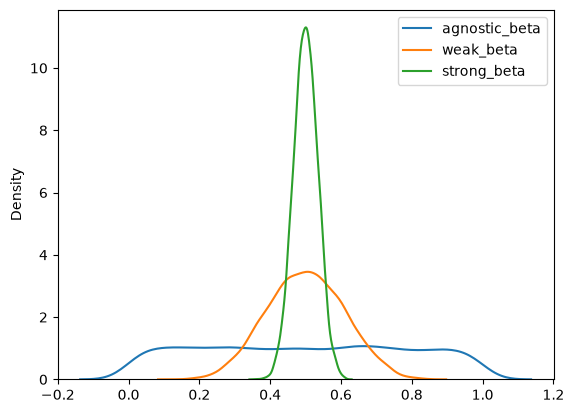

In [164]:
sns.kdeplot(prior1_1, label="agnostic_beta")
sns.kdeplot(prior10_10, label="weak_beta")
sns.kdeplot(prior100_100, label="strong_beta")
plt.legend()
plt.show()

# Simulating A/B test

Our A/B test is measuring conversion rates for two different versions of a website

## Steps:
1. `GOAL`: Defined the aim of the test
2. `PRIOR`: Get the historical information - i.e. previous conversion rate and Set prior based on the previous rate
3. `DATA COLLECTION`: Decide sample size and collect data
4. `SIMULATE DISTRIBUTION`: Apply current data to simulate distributions for control (A) and treatment (B) groups
5. `A/B TEST`: Compare the performance between control (A) and treatment (B) groups
6. `CONCLUSION`: Draw a conclusion

In [165]:
exp = pd.read_csv("experiment_data.csv")

In [166]:
exp.head()

,userId,group,converted
0,824da8778c2942498cd80a85af9a11d9,control,False
1,4742b983a182402eb8adf0a7ff115c0e,treatment,False
2,3c539fbb4e3f4925bfc8224cf396245b,treatment,False
3,03cb93928f1d4da8b411f9c834a5af33,treatment,True
4,4a0fec8e18bc46d4a33fc98947855391,control,False


# Set the goal 

defined the aim of the test 

To evaluate wich version (control(A) or experiment(B) has a beter conversion rate)

# Deciding the prior

In [167]:
# we have so prior data where we know that conversion rate is already 20%

prior_alpha = 20
prior_beta = 80

<Axes: ylabel='Density'>

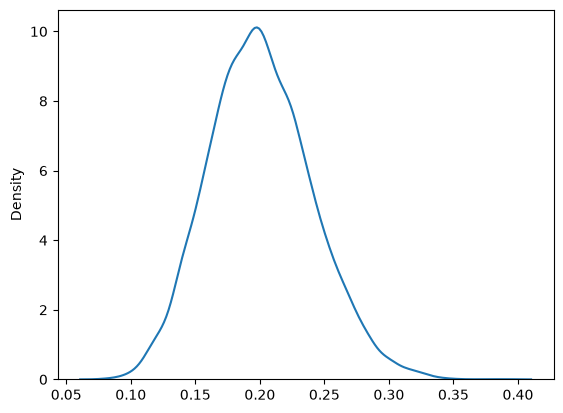

In [168]:
prior_dist = np.random.beta(prior_alpha,prior_beta,10000)
sns.kdeplot(prior_dist)

# control_true & control_false

In [169]:
control_true = exp.loc[exp.group == "control"].converted.sum()

control_false = len(exp.loc[exp.group == "control"]) - control_true 



In [170]:
print("control", control_true)
print("control false", control_false)
print("total", control_false + control_true)


control 406
control false 1594
total 2000


In [171]:
control_post = np.random.beta(prior_alpha + control_true, prior_beta + control_false, 10000)

<Axes: ylabel='Density'>

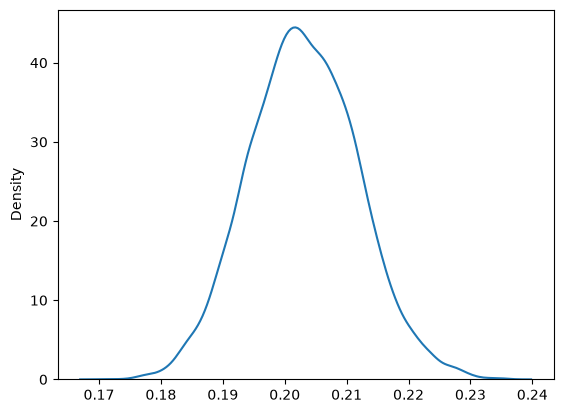

In [172]:
sns.kdeplot(control_post)

In [173]:
control_post.mean()

np.float64(0.20304352377887439)

# treatment_true & treatment_false

In [174]:
treatment_true = exp.loc[exp.group == "treatment"].converted.sum()

treatment_false = len(exp.loc[exp.group == "treatment"]) - control_true 

In [175]:
print("control", treatment_true)
print("control false", treatment_false)
print("total", treatment_false + treatment_true)




control 452
control false 1594
total 2046


# posterior treatment

In [176]:
treatment_post = np.random.beta(prior_alpha + treatment_true, prior_beta + treatment_false, 10000)

<Axes: ylabel='Density'>

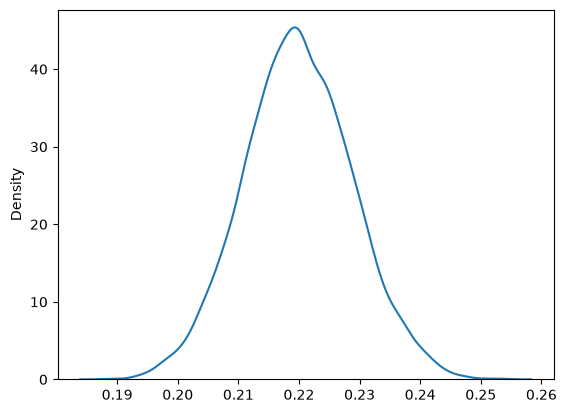

In [177]:
sns.kdeplot(treatment_post)

In [178]:
treatment_post.mean()

np.float64(0.2198586182345147)

Likelyhood of treatment being better

In [179]:
diff = treatment_post - control_post

In [181]:
diff > 0

array([ True,  True,  True, ...,  True,  True,  True], shape=(10000,))

In [ ]:
# percentage
(diff > 0).mean()

np.float64(0.9088)

In [ ]:
pm.stats.hdi(diff, prob = 0.95) 

array([-0.00752433,  0.04155362])

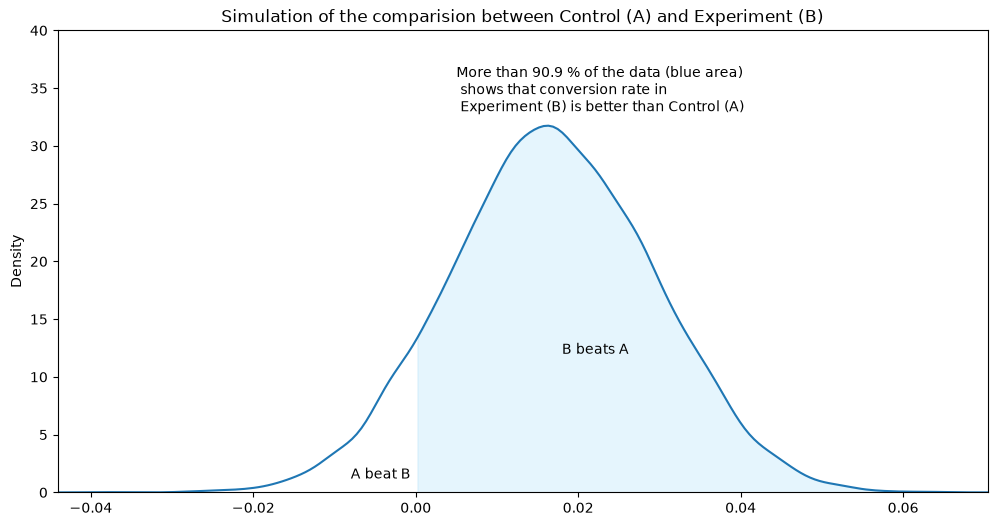

In [186]:
# Visualize the difference between A and B (diff)

from scipy import stats
import scipy

# plot
plt.figure(figsize = (12,6))
ax = sns.kdeplot(diff)

# fill the area greater than 0
l1 = ax.lines[0]
x1 = l1.get_xydata()[:, 0]
y1 = l1.get_xydata()[:, 1]
x_1 = []
y_1 = []
for i, j in zip(x1, y1):
    if i >= 0:
        x_1.append(i)
        y_1.append(j)
ax.fill_between(x_1, y_1, color = '#A9DEF9', alpha=0.3)
ax.margins(x=0, y=0)



#plt.axvline(x = diff.mean()-diff.std()*1.96, label = "95% CI")

# set the y axis
plt.ylim(0,40)
#plt.legend()

# title and annotation
plt.title('Simulation of the comparision between Control (A) and Experiment (B)')
plt.annotate(xy = (0.005, 33), text = f'More than {round((diff > 0).mean()*100,1)} % of the data (blue area) \n shows that conversion rate in \n Experiment (B) is better than Control (A)')
plt.annotate(text = "B beats A", xy = (0.018,12))
plt.annotate(text = "A beat B", xy = (-0.008,1.2))

plt.show()